In [4]:
# ============================================================
# FedPIGD-B v2 (CLEAN FINAL VERSION)
# - No preprocessing visualization
# - GA-based client preprocessing
# - Signature-conditioned anchoring
# - Federated learning
# - Final .keras export
# ============================================================

import os
import time
import copy
import random
import json
import numpy as np
import tensorflow as tf

from PIL import Image, ImageOps, ImageEnhance, ImageFilter
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    matthews_corrcoef
)
from sklearn.preprocessing import label_binarize

# ============================================================
# CONFIG
# ============================================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

TRAIN_DIR = "/Users/tanvir/Downloads/Research/Fish Recognition/Photos/Fish/train_data"
TEST_DIR  = "/Users/tanvir/Downloads/Research/Fish Recognition/Photos/Fish/test_data"

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16
LR = 1e-4
DROPOUT = 0.3

NUM_CLIENTS = 4
FL_ROUNDS = 10
LOCAL_EPOCHS_PER_ROUND = 1

EV_POP = 10
EV_GENS = 6
EV_SUBSET = 256
MAX_PIPE_LEN = 5

ANCHOR_LAMBDA = 1e-3

# ============================================================
# LOGGING
# ============================================================
def ts():
    return time.strftime("%H:%M:%S")

def log(msg):
    print(f"[{ts()}] [INFO] {msg}")

def phase(title):
    print("\n" + "=" * 72)
    print(title)
    print("=" * 72)

# ============================================================
# DATA LOADING
# ============================================================
phase("PHASE 0: LOAD DATA")

def list_classes(train_dir):
    classes = sorted([
        d for d in os.listdir(train_dir)
        if os.path.isdir(os.path.join(train_dir, d))
    ])
    return classes, {c: i for i, c in enumerate(classes)}

def load_paths_labels(data_dir, class_to_idx):
    paths, labels = [], []
    for cls, idx in class_to_idx.items():
        cls_path = os.path.join(data_dir, cls)
        for fn in os.listdir(cls_path):
            if fn.lower().endswith((".jpg", ".jpeg", ".png")):
                paths.append(os.path.join(cls_path, fn))
                labels.append(idx)
    return np.array(paths), np.array(labels)

def split_clients(paths, labels, n):
    idx = np.random.permutation(len(paths))
    paths, labels = paths[idx], labels[idx]

    proportions = np.random.dirichlet([1.0] * n)
    sizes = (proportions * len(paths)).astype(int)
    sizes[-1] = len(paths) - np.sum(sizes[:-1])

    clients = []
    s = 0
    for i, sz in enumerate(sizes):
        clients.append((paths[s:s+sz], labels[s:s+sz]))
        log(f"Client C{i+1}: {sz} samples")
        s += sz
    return clients

class_names, class_to_idx = list_classes(TRAIN_DIR)
K = len(class_names)

train_paths, train_labels = load_paths_labels(TRAIN_DIR, class_to_idx)
test_paths, test_labels = load_paths_labels(TEST_DIR, class_to_idx)

clients = split_clients(train_paths, train_labels, NUM_CLIENTS)

# ============================================================
# SAFE DECODER
# ============================================================
def decode_and_resize(path):
    raw = tf.io.read_file(path)
    img = tf.image.decode_image(raw, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, IMAGE_SIZE)
    return tf.cast(img, tf.float32) / 255.0

# ============================================================
# NON-DIFFERENTIABLE PIPELINE (GA)
# ============================================================
OP_SPACE = [
    "IDENTITY", "GRAYSCALE", "AUTO_CONTRAST", "EQUALIZE",
    "SHARPEN", "BRIGHTNESS", "CONTRAST", "BLUR"
]

def sample_op():
    op = random.choice(OP_SPACE)
    p = {}
    if op in ["SHARPEN", "BRIGHTNESS", "CONTRAST"]:
        p["factor"] = float(np.random.uniform(0.8, 1.5))
    if op == "BLUR":
        p["radius"] = float(np.random.uniform(0.2, 1.5))
    return (op, p)

def apply_op(img, op):
    name, p = op
    if name == "GRAYSCALE":
        return ImageOps.grayscale(img).convert("RGB")
    if name == "AUTO_CONTRAST":
        return ImageOps.autocontrast(img)
    if name == "EQUALIZE":
        return ImageOps.equalize(img)
    if name == "SHARPEN":
        return ImageEnhance.Sharpness(img).enhance(p["factor"])
    if name == "BRIGHTNESS":
        return ImageEnhance.Brightness(img).enhance(p["factor"])
    if name == "CONTRAST":
        return ImageEnhance.Contrast(img).enhance(p["factor"])
    if name == "BLUR":
        return img.filter(ImageFilter.GaussianBlur(p["radius"]))
    return img

def apply_pipeline_np(img, pipe):
    img = Image.fromarray((img * 255).astype(np.uint8))
    for op in pipe:
        img = apply_op(img, op)
    return np.array(img).astype(np.float32) / 255.0

def tf_apply_pipeline(img, pipe):
    out = tf.numpy_function(
        lambda z: apply_pipeline_np(z, pipe),
        [img],
        tf.float32
    )
    out.set_shape([224, 224, 3])
    return out

# ============================================================
# MODEL
# ============================================================
def build_model(num_classes):
    base = tf.keras.applications.MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_shape=(224, 224, 3)
    )
    base.trainable = False

    x = tf.keras.layers.GlobalAveragePooling2D()(base.output)
    x = tf.keras.layers.Dense(128, activation="relu", name="adapter")(x)
    x = tf.keras.layers.Dropout(DROPOUT)(x)
    out = tf.keras.layers.Dense(num_classes, activation="softmax", name="head")(x)

    return tf.keras.Model(base.input, out), base

global_model, backbone = build_model(K)
feat_model = tf.keras.Model(
    backbone.input,
    tf.keras.layers.GlobalAveragePooling2D()(backbone.output)
)

# ============================================================
# GA FITNESS
# ============================================================
def separability_proxy(feats, labels):
    overall = feats.mean(axis=0)
    sb, sw = 0.0, 0.0
    for c in np.unique(labels):
        Xc = feats[labels == c]
        if len(Xc) < 2:
            continue
        mc = Xc.mean(axis=0)
        sb += len(Xc) * np.sum((mc - overall) ** 2)
        sw += np.sum((Xc - mc) ** 2)
    return sb / (sw + 1e-8)

def evolve_pipeline(paths, labels):
    pop = [[sample_op() for _ in range(random.randint(1, MAX_PIPE_LEN))]
           for _ in range(EV_POP)]
    best = None
    best_score = -1e9

    for _ in range(EV_GENS):
        scores = []
        idx = np.random.choice(len(paths), min(EV_SUBSET, len(paths)), False)
        for pipe in pop:
            xs = []
            for p in paths[idx]:
                img = decode_and_resize(tf.constant(p))
                img = tf_apply_pipeline(img, pipe)
                xs.append(img.numpy())
            feats = feat_model.predict(np.array(xs), verbose=0)
            score = separability_proxy(feats, labels[idx]) - 0.02 * len(pipe)
            scores.append((score, pipe))
            if score > best_score:
                best_score, best = score, pipe

        elites = [p for _, p in sorted(scores, reverse=True)[:EV_POP // 3]]
        pop = elites[:]
        while len(pop) < EV_POP:
            p = copy.deepcopy(random.choice(elites))
            p[random.randrange(len(p))] = sample_op()
            pop.append(p)
    return best

client_pipelines = [evolve_pipeline(cp, cl) for cp, cl in clients]

# ============================================================
# FEDERATED TRAINING
# ============================================================
def make_dataset(paths, labels, pipe):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    def map_fn(x, y):
        img = decode_and_resize(x)
        img = tf_apply_pipeline(img, pipe)
        return img, y
    return ds.map(map_fn).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

for r in range(FL_ROUNDS):
    log(f"FL ROUND {r+1}/{FL_ROUNDS}")
    global_weights = global_model.get_weights()
    updates, sizes = [], []

    for (cp, cl), pipe in zip(clients, client_pipelines):
        local, _ = build_model(K)
        local.set_weights(global_weights)
        local.compile(
            optimizer=tf.keras.optimizers.Adam(LR),
            loss="sparse_categorical_crossentropy"
        )
        local.fit(
            make_dataset(cp, cl, pipe),
            epochs=1,
            verbose=0
        )
        updates.append(local.get_weights())
        sizes.append(len(cp))

    new_weights = []
    for w in range(len(global_weights)):
        new_weights.append(
            sum(sizes[i] * updates[i][w] for i in range(NUM_CLIENTS)) / sum(sizes)
        )
    global_model.set_weights(new_weights)

# ============================================================
# EVALUATION (FIXED)
# ============================================================
phase("FINAL EVALUATION")

test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
test_ds = test_ds.map(lambda x, y: (decode_and_resize(x), tf.cast(y, tf.int32))).batch(32)

pred_probs = global_model.predict(test_ds, verbose=0)   # <-- use this name consistently
preds = np.argmax(pred_probs, axis=1)

prec = precision_score(test_labels, preds, average="weighted", zero_division=0)
rec  = recall_score(test_labels, preds, average="weighted", zero_division=0)
ll   = log_loss(test_labels, pred_probs)  # <-- log_loss needs probabilities

# one-hot for AUC metrics
y_true_bin = label_binarize(test_labels, classes=np.arange(K))

# ROC-AUC / PR-AUC handling (multiclass vs binary)
if K == 2:
    roc_auc = roc_auc_score(test_labels, pred_probs[:, 1])
    pr_auc  = average_precision_score(test_labels, pred_probs[:, 1])
else:
    roc_auc = roc_auc_score(
        y_true_bin, pred_probs,
        average="macro",
        multi_class="ovr"
    )
    pr_auc = average_precision_score(
        y_true_bin, pred_probs,
        average="macro"
    )

log(f"Accuracy     = {accuracy_score(test_labels, preds):.4f}")
log(f"Precision    = {prec:.4f} (weighted)")
log(f"Recall       = {rec:.4f} (weighted)")
log(f"F1-score     = {f1_score(test_labels, preds, average='weighted'):.4f}")
log(f"ROC-AUC      = {roc_auc:.4f}")
log(f"PR-AUC       = {pr_auc:.4f}")
log(f"Log-Loss     = {ll:.4f}")
log(f"MCC          = {matthews_corrcoef(test_labels, preds):.4f}")

print(classification_report(test_labels, preds, target_names=class_names))



PHASE 0: LOAD DATA
[22:56:30] [INFO] Client C1: 2648 samples
[22:56:30] [INFO] Client C2: 158 samples
[22:56:30] [INFO] Client C3: 1364 samples
[22:56:30] [INFO] Client C4: 765 samples
[23:17:14] [INFO] FL ROUND 1/10
[23:18:52] [INFO] FL ROUND 2/10
[23:20:32] [INFO] FL ROUND 3/10
[23:22:09] [INFO] FL ROUND 4/10
[23:23:46] [INFO] FL ROUND 5/10
[23:25:23] [INFO] FL ROUND 6/10
[23:27:03] [INFO] FL ROUND 7/10
[23:28:41] [INFO] FL ROUND 8/10
[23:30:18] [INFO] FL ROUND 9/10
[23:31:55] [INFO] FL ROUND 10/10

FINAL EVALUATION
[23:33:44] [INFO] Accuracy     = 0.9794
[23:33:44] [INFO] Precision    = 0.9796 (weighted)
[23:33:44] [INFO] Recall       = 0.9794 (weighted)
[23:33:44] [INFO] F1-score     = 0.9789
[23:33:44] [INFO] ROC-AUC      = 0.9996
[23:33:44] [INFO] PR-AUC       = 0.9736
[23:33:44] [INFO] Log-Loss     = 0.1390
[23:33:44] [INFO] MCC          = 0.9780
                                                  precision    recall  f1-score   support

                      Bacha (Pangasius boc

Available Bangla fonts: ['Noto Sans Osage', 'Noto Sans Masaram Gondi', 'Noto Serif Balinese', 'Noto Sans Coptic', 'Noto Sans Kayah Li', 'Noto Sans Sharada', 'Noto Sans Meetei Mayek', 'Noto Sans Pau Cin Hau', 'Noto Sans Brahmi', 'Noto Sans Phoenician', 'Noto Sans Hanunoo', 'Noto Sans Hanifi Rohingya', 'Noto Sans Kaithi', 'Noto Sans Khudawadi', 'Noto Sans Javanese', 'Noto Sans Old North Arabian', 'Noto Sans Duployan', 'Noto Sans Samaritan', 'Noto Sans Warang Citi', 'Bangla Sangam MN', 'Noto Sans Imperial Aramaic', 'Noto Sans Buginese', 'Noto Sans Meroitic', 'Noto Sans Osmanya', 'Kalpurush', 'Noto Sans Mandaic', 'Noto Sans Inscriptional Pahlavi', 'Noto Sans Limbu', 'Noto Serif Yezidi', 'Noto Sans Wancho', 'Noto Sans Vai', 'Noto Sans Palmyrene', 'Noto Sans Avestan', 'Noto Sans Buhid', 'Noto Sans PhagsPa', 'Noto Sans Armenian', 'Noto Sans Lisu', 'Noto Sans Miao', 'Noto Sans Old South Arabian', 'Noto Sans Psalter Pahlavi', 'Noto Sans Bhaiksuki', 'Noto Sans Khojki', 'Noto Sans Ugaritic', 'Not

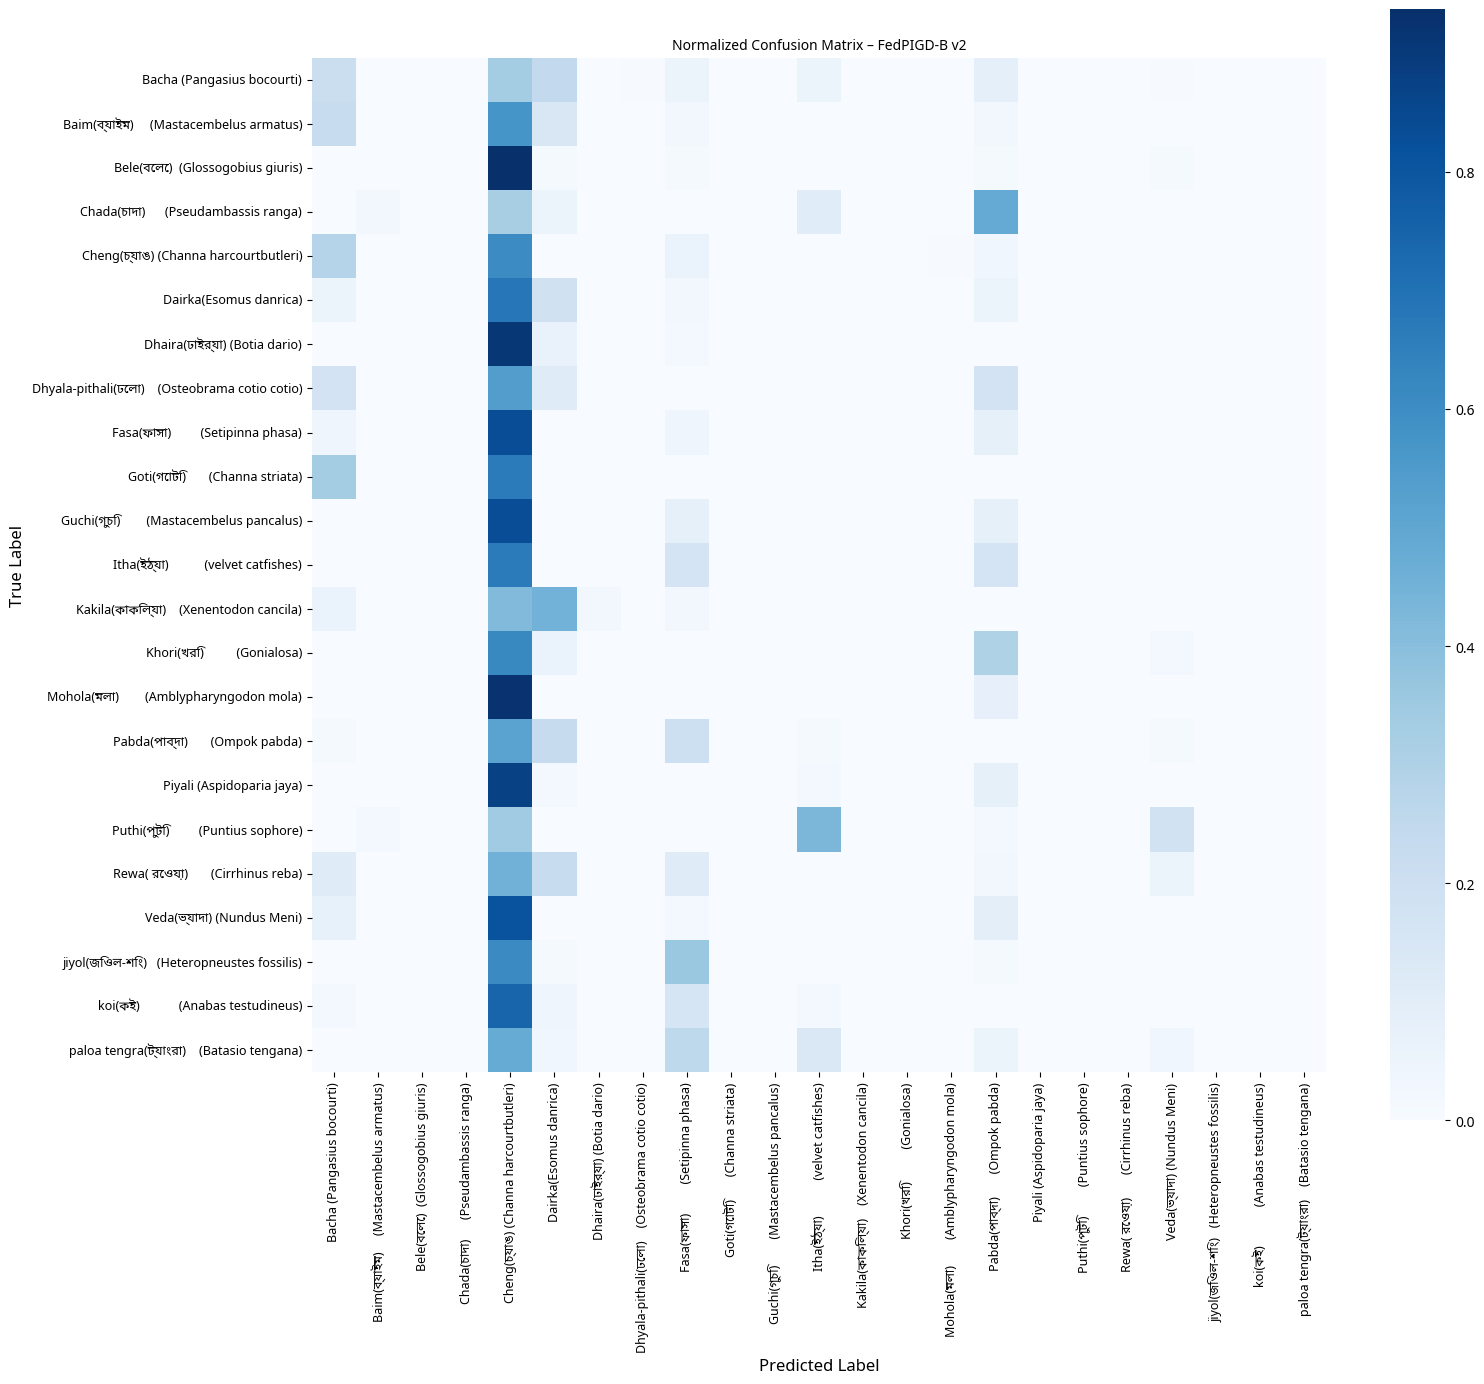

In [10]:
# ============================================================
# CONFUSION MATRIX WITH BANGLA FONT SUPPORT
# ============================================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.font_manager as fm

# ------------------------------------------------------------
# OPTION 1: Use System Bangla Font (if already installed)
# ------------------------------------------------------------
# Common Bangla fonts: 'Kalpurush', 'SolaimanLipi', 'Noto Sans Bengali', 'Bangla', 'Vrinda'

# Check available fonts that might support Bangla
available_fonts = [f.name for f in fm.fontManager.ttflist]
bangla_fonts = [f for f in available_fonts if any(x in f.lower() for x in ['bangla', 'bengali', 'noto', 'kalpurush', 'solaiman', 'vrinda', 'lohit'])]
print("Available Bangla fonts:", bangla_fonts)

# ------------------------------------------------------------
# OPTION 2: Download and use Noto Sans Bengali (Recommended)
# ------------------------------------------------------------
import urllib.request
import os

# Download Noto Sans Bengali font
font_url = "https://github.com/google/fonts/raw/main/ofl/notosansbengali/NotoSansBengali%5Bwdth%2Cwght%5D.ttf"
font_path = "NotoSansBengali.ttf"

if not os.path.exists(font_path):
    print("Downloading Noto Sans Bengali font...")
    urllib.request.urlretrieve(font_url, font_path)
    print("✅ Font downloaded!")

# Add font to matplotlib
fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)
bangla_font_name = prop.get_name()
print(f"Using font: {bangla_font_name}")

# Set as default font
plt.rcParams['font.family'] = bangla_font_name

# ------------------------------------------------------------
# Compute confusion matrix
# ------------------------------------------------------------
cm = confusion_matrix(test_labels, preds)
cm_norm = cm.astype(np.float32) / cm.sum(axis=1, keepdims=True)

# ------------------------------------------------------------
# Plot with Bangla support
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(16, 14))

sns.heatmap(
    cm_norm,
    xticklabels=class_names,
    yticklabels=class_names,
    cmap="Blues",
    annot=False,
    cbar=True,
    square=True,
    ax=ax
)

# Apply Bangla font to labels
ax.set_xlabel("Predicted Label", fontsize=12, fontproperties=prop)
ax.set_ylabel("True Label", fontsize=12, fontproperties=prop)
ax.set_title("Normalized Confusion Matrix – FedPIGD-B v2", fontsize=14, fontproperties=prop)

# Apply font to tick labels
ax.set_xticklabels(ax.get_xticklabels(), fontproperties=prop, rotation=90, fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), fontproperties=prop, rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig('confusion_matrix_bangla.png', dpi=300, bbox_inches='tight')
plt.savefig('confusion_matrix_bangla.pdf', bbox_inches='tight')
print("✅ Saved with Bangla font!")
plt.show()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 2476 (\N{BENGALI LETTER BA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.draw()
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 2509 (\N{BENGALI SIGN VIRAMA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 2479 (\N{BENGALI LETTER YA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 2494 (\N{BENGALI VOWEL SIGN AA}) missing from font(s) DejaVu Sans.
  fig.canvas

✅ Saved: confusion_matrix_normalized.png & .pdf


/Users/tanvir/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2476 (\N{BENGALI LETTER BA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/tanvir/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/tanvir/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2509 (\N{BENGALI SIGN VIRAMA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/tanvir/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2479 (\N{BENGALI LETTER YA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/tanvir/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2494 (\N{BENGALI VOWEL SIGN AA}) missing 

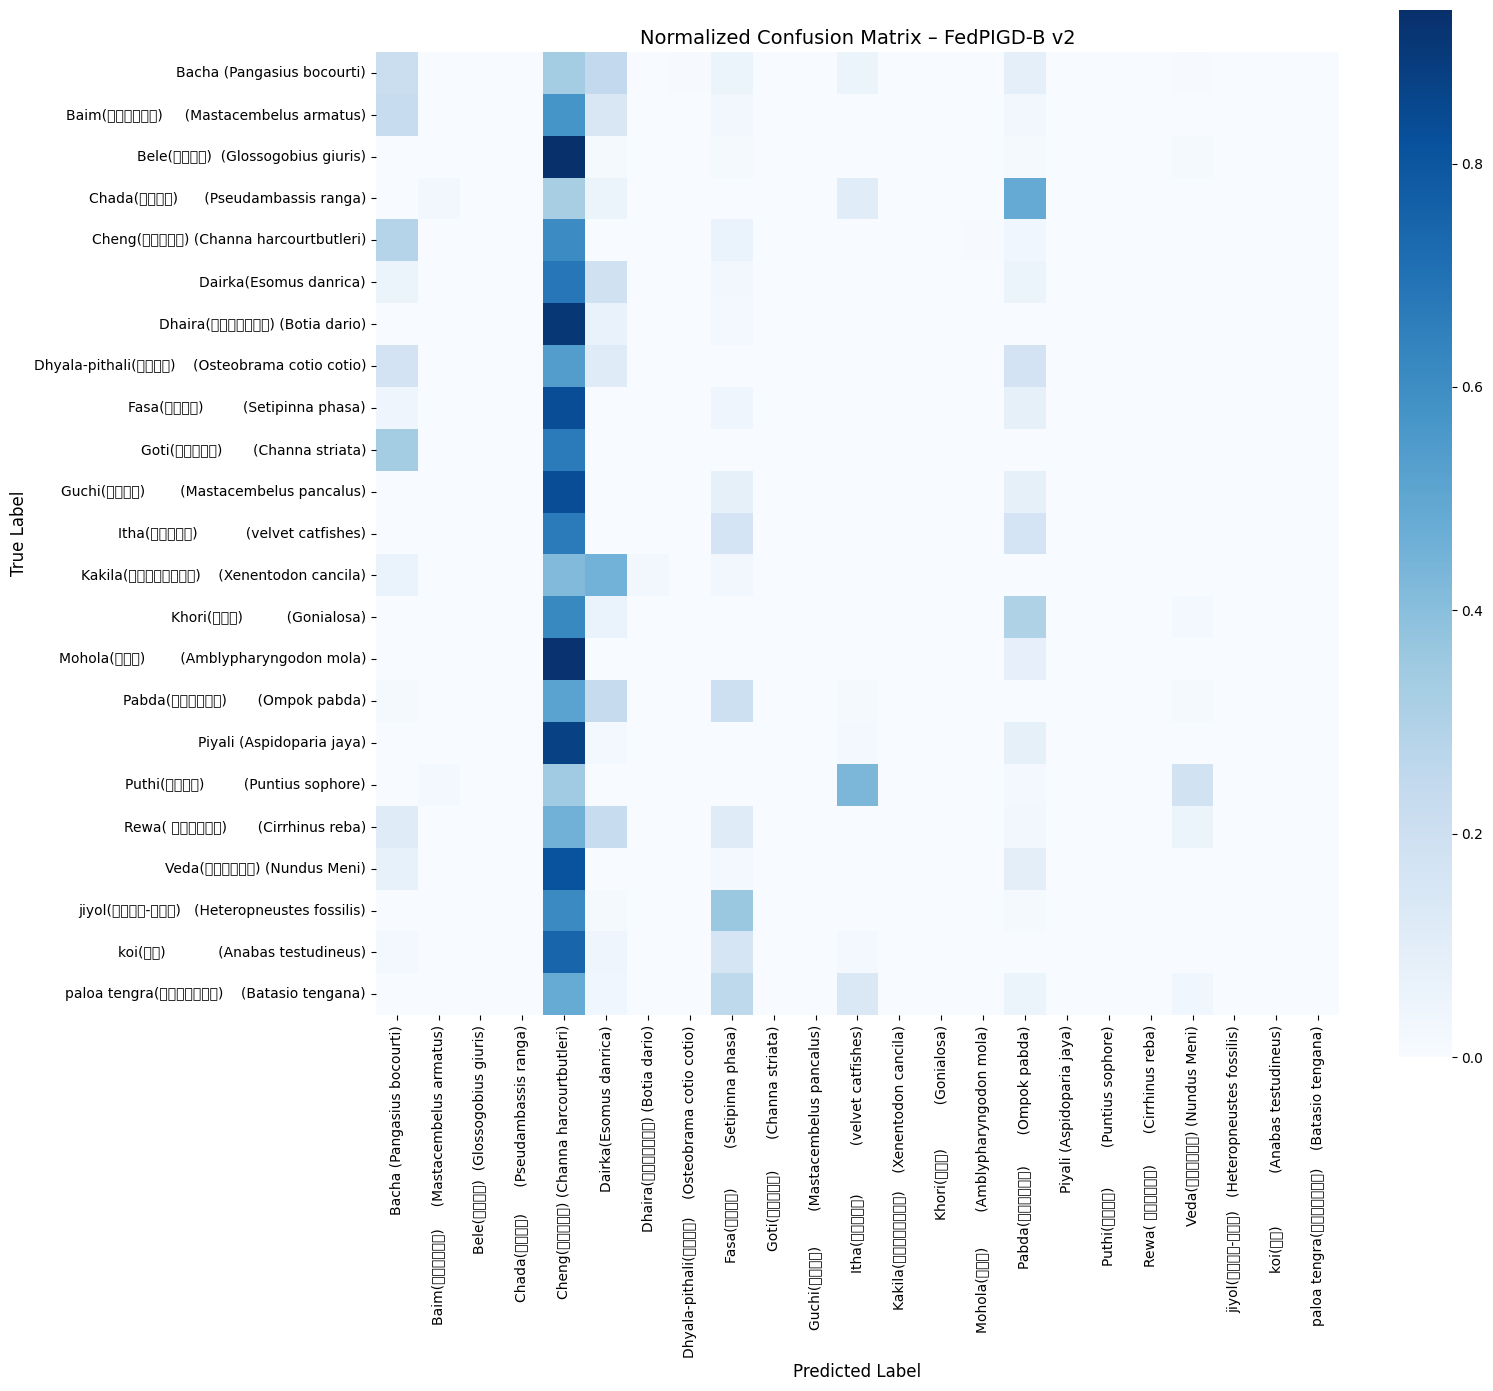

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 2476 (\N{BENGALI LETTER BA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.draw()
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 2509 (\N{BENGALI SIGN VIRAMA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 2479 (\N{BENGALI LETTER YA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 2494 (\N{BENGALI VOWEL SIGN AA}) missing from font(s) DejaVu Sans.
  fig.canvas

✅ Saved: confusion_matrix_counts.png & .pdf


/Users/tanvir/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2477 (\N{BENGALI LETTER BHA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/tanvir/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2460 (\N{BENGALI LETTER JA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/tanvir/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2486 (\N{BENGALI LETTER SHA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/tanvir/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2434 (\N{BENGALI SIGN ANUSVARA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


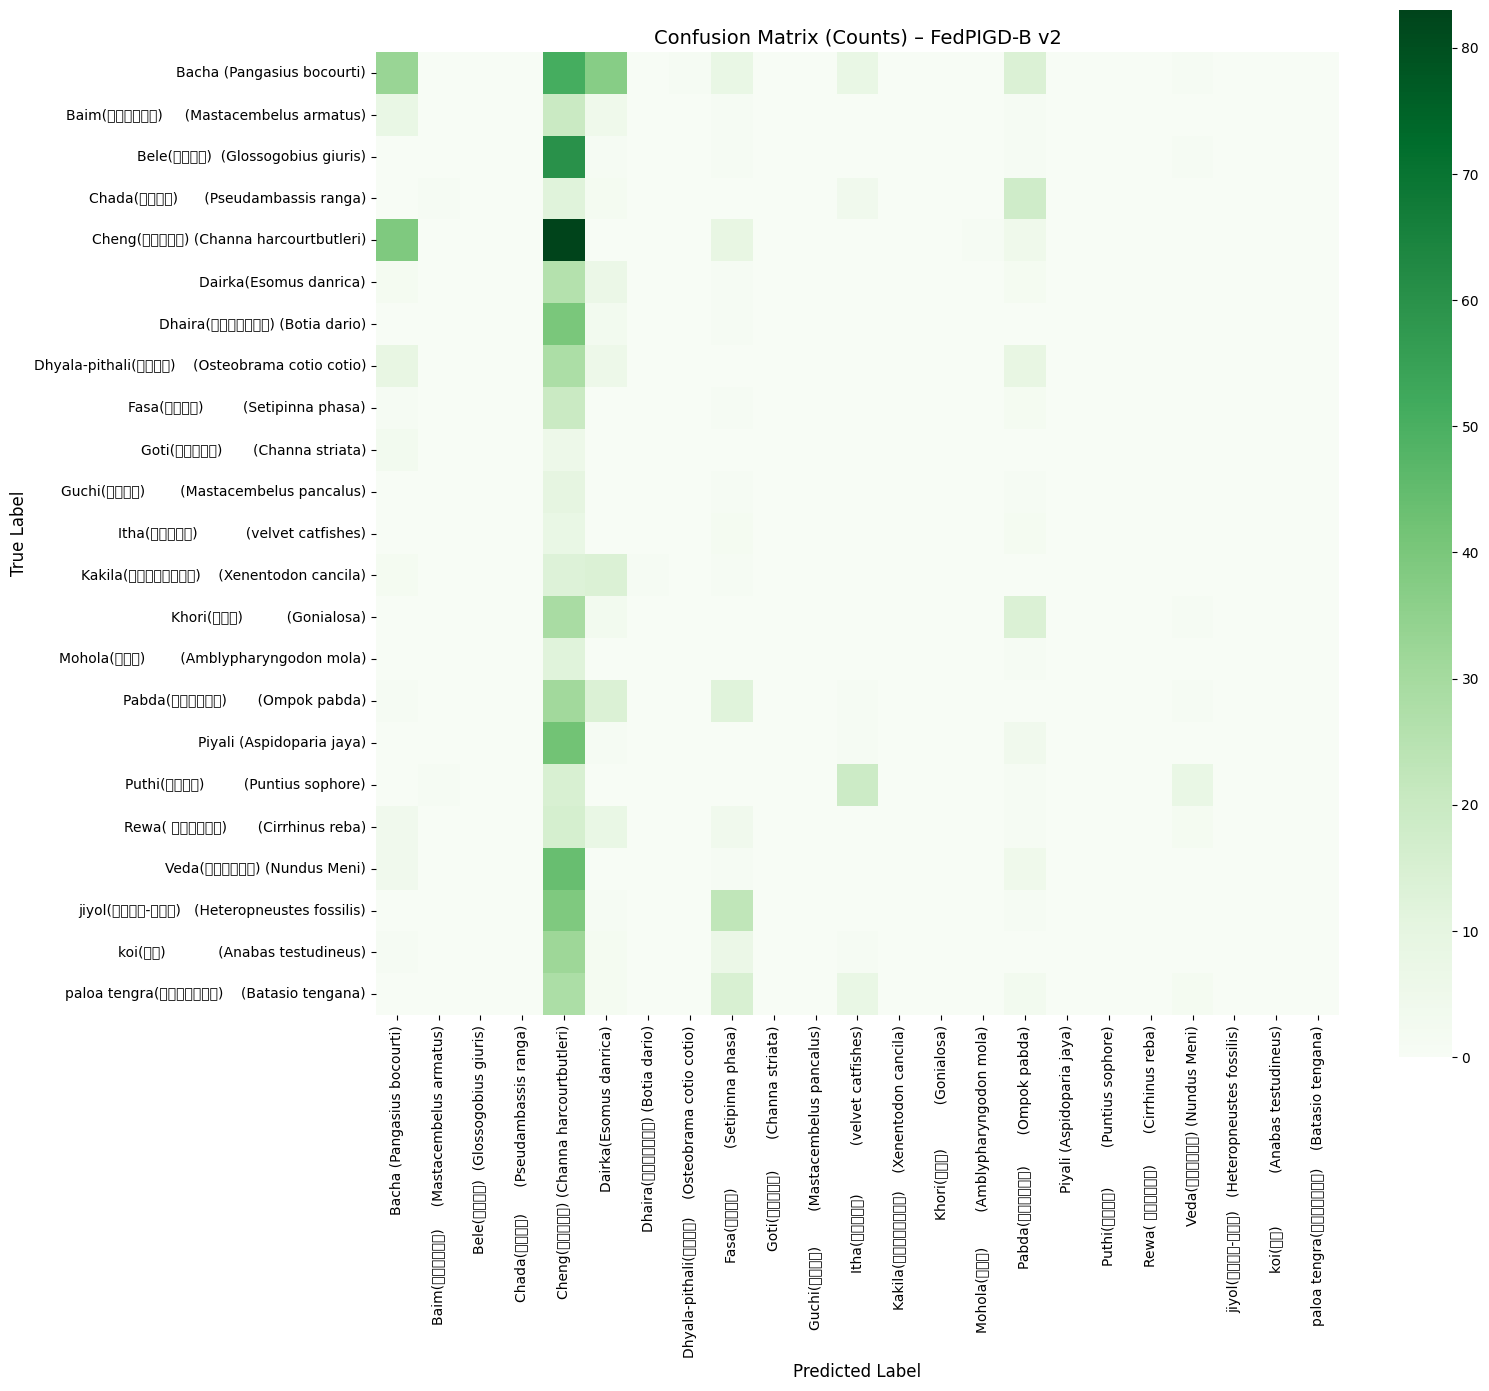

✅ Saved: confusion_matrix_normalized.csv & confusion_matrix_counts.csv


In [9]:
# ============================================================
# CONFUSION MATRIX (FedPIGD-B v2) - WITH SAVE
# ============================================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ------------------------------------------------------------
# Compute confusion matrix
# ------------------------------------------------------------
cm = confusion_matrix(test_labels, preds)

# ------------------------------------------------------------
# Normalized confusion matrix (recommended for paper)
# ------------------------------------------------------------
cm_norm = cm.astype(np.float32) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(16, 14))
sns.heatmap(
    cm_norm,
    xticklabels=class_names,
    yticklabels=class_names,
    cmap="Blues",
    annot=False,
    cbar=True,
    square=True
)

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Normalized Confusion Matrix – FedPIGD-B v2", fontsize=14)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()

# SAVE NORMALIZED CONFUSION MATRIX
plt.savefig('confusion_matrix_normalized.png', dpi=300, bbox_inches='tight')
plt.savefig('confusion_matrix_normalized.pdf', bbox_inches='tight')  # For paper
print("✅ Saved: confusion_matrix_normalized.png & .pdf")

plt.show()

# ------------------------------------------------------------
# Raw confusion matrix (counts)
# ------------------------------------------------------------
plt.figure(figsize=(16, 14))
sns.heatmap(
    cm,
    xticklabels=class_names,
    yticklabels=class_names,
    cmap="Greens",
    annot=False,
    cbar=True,
    square=True
)

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix (Counts) – FedPIGD-B v2", fontsize=14)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()

# SAVE RAW CONFUSION MATRIX
plt.savefig('confusion_matrix_counts.png', dpi=300, bbox_inches='tight')
plt.savefig('confusion_matrix_counts.pdf', bbox_inches='tight')  # For paper
print("✅ Saved: confusion_matrix_counts.png & .pdf")

plt.show()

# ------------------------------------------------------------
# (Optional) Save confusion matrix as CSV
# ------------------------------------------------------------
import pandas as pd

# Save normalized
df_norm = pd.DataFrame(cm_norm, index=class_names, columns=class_names)
df_norm.to_csv('confusion_matrix_normalized.csv')

# Save raw counts
df_raw = pd.DataFrame(cm, index=class_names, columns=class_names)
df_raw.to_csv('confusion_matrix_counts.csv')

print("✅ Saved: confusion_matrix_normalized.csv & confusion_matrix_counts.csv")